# Cinemática de un Movimiento Curvilíneo: Aceración normal y tangente

In [1]:
%%capture
# @title Latex para Google colab


# !apt-get update
# !apt-get install -y texlive-latex-base texlive-fonts-recommended texlive-fonts-extra dvipng cm-super
# !apt-get install -y texlive-latex-extra dvipng cm-super



In [2]:
# @title Drive para Google Colab

# import sys
# from google.colab import drive
# drive.mount('/content/drive')

# # Agregar la carpeta donde está helpers.py
# sys.path.append('/content/drive/MyDrive/ColabNotebooks/Unitec/Dinámica/'

In [3]:
%%capture
# @title Dependencias Python

import matplotlib.pyplot as plt
import matplotlib
import sympy as sp
import sys
import importlib
from IPython.display import Latex, clear_output
import numpy as np
from scipy.optimize import bisect
import ipywidgets as widgets

# %matplotlib inline
%matplotlib ipympl


# Agregar la carpeta donde está helpers.py
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Unitec/Dinámica/')

import helpers as hl
importlib.reload(hl)

hl.reset_equations()

a, a_t, a_n, v, s, t, x, y, rho, dydx, dydx2 = sp.symbols("a, a_t, a_n, v, s, t, x, y, rho, dy/dx, d^{2}y/dx^2", real = True)
sp.init_printing()

## Ejemplo 1
El automóvil de la figura pasa por el punto $A$, donde $x = 100 \mathrm{\,m}$ moviéndose a $25 \mathrm{\,m/s}$. Su velocidad se define como $v = (25 - 0.15s) \mathrm{[\,m/s\,]}$. Determine la magnitud de su aceleración cuando llega a $B$, donde $s = 51.5\, \mathrm{m}$. La coordenada $x$ en el punto $B$ es $x_B=50\,\mathrm{m}$.
<br>
<a name="ys"></a>
$$ y = 16 - \frac{1}{625}x^2 \:\mathrm{[\,m\,]} \tag{1}$$

<div style="text-align: center">
<img src="https://external-content.duckduckgo.com/iu/?u=http%3A%2F%2Fdrive.google.com/uc?id=11O_bOE4NOfX5YBdvqJKNrXiI2TJXTGrK" alt="Ejercicio 2" width="1000">
</div>



### Componentes tangencial y normal
<!-- $\renewcommand{\d}[1]{\operatorname{d}\!{#1}}$ -->
Se nos da la rapidez de la partícula como una función de la posición $s$ a lo largo de la trayectoria:  
<a name="vs"></a>
$$v = (25 - 0.15s) \mathrm{[\,m/s\,]} \tag{2}$$  
 Recordamos que las diferentes componentes del moviimiento se pueden analizar por separado como si se tratase de movimiento rectilíneo i.e.unidimensional. Este principio sigue siendo válido tanto si las componentes son rectangulares ($\boldsymbol{\hat{\imath}}$, $\boldsymbol{\hat{\jmath}}$ y $\boldsymbol{\hat{k}}$) como si las componentes son tangente, normal y binormal ($\boldsymbol{\hat{u_t}}$, $\boldsymbol{\hat{u_n}}$ y $\boldsymbol{\hat{u_b}}$).  
Por lo tanto, podemos evaluar cada una de estas componentes independientemente de las demás.



#### Componente tangencial
Si tenemos la rapidez (que por definición es *tangencial*$\,$) en términos de la posición $s$ nodeltiempo podemos usar la equación diferencial:
<a name="EqDif_at"></a>
$$a_t\operatorname{d}{s}=v\operatorname{d}{v} \tag{3}$$

Como no conocemos $a_t$ en términos de $s$, no podemos integrar directamente. Pero podemos separar las variables:
<a name="a_t=vdvds"></a>
$$a_t = v\,\frac{\operatorname{d}{v}}{\operatorname{d}{s}} \tag{4}$$
<br>

Si reemplazamos [$(2)$](#v(s)) en [$(4)$](#a_t=vdvds):
<a name="a_t(s)"></a>
$$ a_{t}{\left(s \right)} = \left(25.0 - 0.15 s\right) \left(-0.15\right) \tag{5} $$
<br><br>

Al evaluar en $B$, donde $s=51.5$ :
<a name="a_t_B"></a>
$$ a_{t} = \left(25.0 - 0.15 \cdot 51.5\right) \left(-0.15\right) = -2.59 \mathrm{\,m/s^2} \tag{6} $$

In [4]:
%%capture
# @title

su = sp.UnevaluatedExpr(s)
y = 16 - (1/625)*x**2
v = 25 - 0.15*s
a_t = v * sp.diff(v, s).subs(s, su)


su = sp.UnevaluatedExpr(s)

ats = sp.Eq(sp.S('a_t(s)'),sp.Mul((a_t/-0.15),-0.15, evaluate=False))
ats2 = sp.Eq(sp.S('a_t'),sp.Mul((a_t/-0.15),-0.15, evaluate=False))
hl.write_latex_equation(sp.latex(ats), 5, 'a_t(s)', 5)
display(ats)


a_t_B_sus = hl.raw_subs(ats2, {s: 51.5}, rationalize= False)
a_t_B_eval = sp.N(a_t_B_sus.doit(), 3).rhs
# display(a_t_B_sus)
# display(a_t_B_eval)

a_t_B = hl.add_unit_latex(hl.eq_chain_latex(a_t_B_sus, a_t_B_eval), 'm/s^2')

display(Latex(a_t_B))
hl.write_latex_equation(a_t_B, 6, 'a_t_B', 6)

#### Componente normal
Para la componente normal de la aceleración:
<a name="a_n(v)"></a>
$$ a_{n} = \frac{v^{2}}{\rho} \tag{7} $$
<br>

Donde el radio de curvatura está definido como:
<a name = "rho"></a>
$$ \rho = \frac{\left(\left(\frac{\operatorname{d}{y}}{\operatorname{d}{x}}\right)^2 + 1\right)^\frac{3}{2} }{\left|\frac{\operatorname{d}^2 \! y}{\operatorname{d}{x}^2}\right|} \tag{8}$$
<br>

Calculando las derivadas:
<a name = "dydx"></a>
$$\\[0.1em]$$
$$
\begin{array}{c c c  c c c}
\hspace{0.5cm} &
\displaystyle \frac{dy}{dx} = -\frac{2}{625}x &
\hspace{0.5cm} & \hspace{0.5cm}
\displaystyle \frac{d^2y}{dx^2} = -\frac{2}{625}
\hspace{0.5cm}
\tag{9, 10}
\end{array}$$
$$\\[0.1em]$$
<br><br>

Si reemplazamos [$(9)$](#dydx) y [$(10)$](#dydx) en [$(8)$](#rho):
<a name="rho(x)"></a>
$$ \rho = \frac{\left(\left(- \frac{2 x}{625}\right)^{2} + 1\right)^{\frac{3}{2}}}{\left|{- \frac{2}{625}}\right|} $$

<br><br>


Al evaluar en $B$, donde $x=50$ :
<a name="rho_B"></a>
$$ \rho = \frac{\left(\left(\left(- \frac{2}{625}\right) 50\right)^{2} + 1\right)^{\frac{3}{2}}}{\left|{- \frac{2}{625}}\right|} = 324.58 \mathrm{\,m} \tag{11} $$

In [5]:
%%capture
# @title

from sre_compile import dis
# dydx = sp.diff(y, x)
# dydx2 = sp.diff(y, x, 2)
rho_1 = sp.Add(1, dydx**2, evaluate=False)**(3/2) / sp.Abs(dydx2)

a_n = v**2/rho
a_n_v = sp.Eq(sp.S('a_n'), sp.S('v')**2/rho)
hl.write_latex_equation(sp.latex(a_n_v), 7, 'a_n(v)', 7)
display(a_n_v)



dx = sp.nsimplify(sp.diff(y, x), rational=True).expand()
hl.write_latex_equation(sp.latex(dx), 9, 'dydx', 9)
display(dx)

dx2 = sp.nsimplify(sp.diff(y, x, 2), rational=True).expand()
hl.write_latex_equation(sp.latex(dx2), 10, '', 10)
display(dx2)

rho_x = sp.Eq(sp.S('rho'),hl.raw_subs(rho_1, {dydx: sp.diff(y, x), dydx2: sp.diff(y, x, 2)}))
hl.write_latex_equation(sp.latex(rho_x), 11, 'rho(x)')
display(rho_x)


rho_subs = hl.raw_subs(rho_x, {x: 50})
rho_eval = sp.N(rho_subs.rhs.doit(), 5)
display(rho_subs)
display(rho_eval)

rho_B = hl.add_unit_latex(hl.eq_chain_latex(rho_subs, rho_eval), 'm')
hl.write_latex_equation(rho_B, 12, 'rho_B', 11)
display(Latex(rho_B))

Si reemplazamos nuestra expresión para la velocidad de [$(2)$](#v(s)) en [$(7)$](#a_n(v)):
<a name="a_n(s)"></a>
$$ a_{n} = \frac{v^{2}}{\rho} = \frac{\left(25 - 0.15 s\right)^{2}}{\rho} \tag{12} $$
<br><br>

Y evaluando en $B$:
<a name="a_n_B"></a>
$$ a_{n} = \frac{\left(25 - 0.15 \cdot 51.5\right)^{2}}{324.58} = 0.92 \mathrm{\,m/s^2} \tag{13} $$

In [6]:
%%capture
# @title

a_n_s_1 = hl.raw_subs(a_n_v, {sp.S('v'): v}, rationalize=False)
display(a_n_v)
display(a_n_s_1)

a_n_s = hl.eq_chain_latex(a_n_v, a_n_s_1.rhs)


hl.write_latex_equation(a_n_s, 13, 'a_n(s)', 12)
hl.dLatex(a_n_s)

a_n_B_sus = hl.raw_subs(a_n_s_1, {s: 51.5, rho: rho_eval}, rationalize=False)
display(a_n_B_sus)
a_n_B_eval = sp.N(a_n_B_sus.rhs.doit(), 2)
display(a_n_B_eval)
a_n_B = hl.add_unit_latex(hl.eq_chain_latex(a_n_B_sus, a_n_B_eval), 'm/s^2')
hl.write_latex_equation(a_n_B, 14, 'a_n_B', 13)
hl.dLatex(a_n_B)
#

### Aceleración Total en B

Conocemos ya la aceleración normal y tangente en el punto $B$ de las ecuaciones [$(6)$](#a_t_B) y [$(13)$](#a_n_B):

$$\\[0.1em]$$
$$ a_{t} = \left(25.0 - 0.15 \cdot 51.5\right) \left(-0.15\right) = -2.59 \mathrm{\,m/s^2} \tag{6} $$
$$\\[0.1em]$$
$$ a_{n} = \frac{\left(25 - 0.15 \cdot 51.5\right)^{2}}{324.58} = 0.92 \mathrm{\,m/s^2} \tag{13} $$
$$\\[0.1em]$$
<br><br>

La aceleración total se encuentra por Teorema de Pitágoras:
<a name="a"></a>
$$ a = \sqrt{a_{n}^{2} + a_{t}^{2}} \tag{14} $$
<br><br>

Reemplazando [$(6)$](#a_t_B) y [$(13)$](#a_n_B) en [$(14)$](#a):
<a name="a_B"></a>
$$ a_{B} = \sqrt{{0.92}^{2} + {\left(-2.59\right)}^{2}} = 2.75 \mathrm{\,m/s^2} \tag{15} $$

In [7]:
%%capture
# @title

a = sp.sqrt(sp.S('a_t')**2 + sp.S('a_n')**2)
a_eq = sp.Eq(sp.S('a'), a)

hl.write_latex_equation(sp.latex(a_eq), 15, 'a', 14)
display(a_eq)

a_sub = hl.raw_subs(a_eq,{sp.S('a'): sp.Symbol('a_B'), sp.S('a_t'): a_t_B_eval,
                          sp.S('a_n'): a_n_B_eval}, rationalize= False)
display(a_sub)

a_eval = sp.N(a_sub.rhs.doit(), 3)
display(a_eval)

a_B = hl.add_unit_latex(hl.eq_chain_latex(a_sub, a_eval), 'm/s^2')
hl.write_latex_equation(a_B, 16, 'a_B', 15)
hl.dLatex(a_B)

In [8]:
%%capture
# @title Relaciones Matemáticas

dy = sp.Function("y'")(x)
t = sp.Symbol("t", real=True)

y_lamb = hl.Lamb(y, x)
dy_lamb = hl.Lamb(sp.diff(y, x), x)
dy2_lamb = hl.Lamb(sp.diff(y, x, 2), x)
hl.d_Eq('y(x)',y)


t_s = sp.integrate(1/v, (s, 0, sp.Symbol('s(t)'))).subs(sp.Symbol('s(t)'), s)
hl.d_Eq('t(s)',t_s)

s_t = sp.Eq(sp.S('s'), *sp.solve(sp.Eq(t, t_s), s))
s_t_lamb = hl.Lamb(s_t.rhs, t)
hl.d_Eq('s(t)', s_t.rhs)

v_t = sp.diff(s_t.rhs, t)
v_t_lamb = hl.Lamb(v_t, t)
hl.d_Eq('v(t)', v_t)

a_t_t = sp.diff(v_t, t)
hl.d_Eq('a_{t}(t)', a_t_t)
a_t_t_lamb = hl.Lamb(a_t_t, t)

a_n_t = v_t**2/rho_x.rhs
hl.d_Eq('a_{n}(t,x)', a_n_t)
hl.d_Eq('rho(x)', rho_x.rhs)
rho_x_lamb = hl.Lamb(rho_x.rhs, x)

s_x = sp.integrate(sp.sqrt(1 + sp.diff(y,x)**2), (x, sp.S('x_t'), 100)).subs(sp.S('x_t'), x)
hl.d_Eq('s(x)', s_x)


# Solución numérica para x(s)
s_x_lamb = sp.lambdify(x, s_x, "numpy")

x_s = lambda s: hl.invert_numeric(s_x_lamb, s, -150, 200)

In [9]:
# @title Funciones de Python a partir de las Relaciones Matemáticas
def x_t(t):
  return x_s(s_t_lamb(t))

def dy_t(t):
  return dy_lamb(x_t(t))

def dy2_t(t):
  return dy2_lamb(x_t(t))

def conc(t):
  return np.sign(dy2_t(t))

def sign_dxdt(t, eps_t = 0.01):
  t1 = t
  t2 = t + eps_t
  return np.sign(x_t(t2) - x_t(t1))

def rho_t(t):
  return rho_x_lamb(x_t(t))



def u_t_t(t):
  dy = dy_t(t)
  return sign_dxdt(t)*(1/np.sqrt(1+(dy**2)))*np.array([1, dy])

def u_n_t(t):
  ut = u_t_t(t)
  return (sign_dxdt(t)*conc(t))*np.array([-ut[1], ut[0]])



def v_t(t):
  return v_t_lamb(t)

def a_t_t(t):
  return a_t_t_lamb(t)

def a_n_t(t):
  return v_t(t)**2/rho_t(t)


def rvec_t(t):
  xt = x_t(t)
  yt = y_lamb(xt)
  return np.array([xt, yt])

def vvec_t(t):
  return v_t(t)*u_t_t(t)

def avec_t(t):
  return a_t_t(t)*u_t_t(t) + a_n_t(t)*u_n_t(t)

def at_vec_t(t):
  return a_t_t(t)*u_t_t(t)

def an_vec_t(t):
  return a_n_t(t)*u_n_t(t)

In [69]:
# @title Elegir tema para gráficas

''' Elegir entre:
tema = 'blanco'
tema = 'cobalto'
tema = 'catpuccin latte'
'''

tema = 'catpuccin latte'

In [70]:
# @title Tema para gráficas

from matplotlib import rcParams
from cycler import cycler

if tema == 'blanco':
  edge_color = '#999999'
  text_color = '#000000'
  figure_color = '#ffffff'
  axes_color = '#ffffff'


  color_palette=[
      '#1a921c',
      '#321A91',
      '#914F1A',
      '#235224',
      '#4F4282',
      '#FFB980',
      ]
elif tema == 'catpuccin latte':
  edge_color = '#999999'
  text_color = '#000000'
  figure_color = '#EFF1F5'
  axes_color = '#F5F7FA'


  color_palette=[
      '#1a921c',
      '#321A91',
      '#914F1A',
      '#235224',
      '#4F4282',
      '#FFB980',
      ]
elif tema == 'cobalto':
  edge_color = '#B5C9D7'
  text_color = '#ffffff'
  figure_color = '#1c3c53'
  axes_color = '#1E4159'


  color_palette=[
      '#57B9FF',
      '#FF5A57',
      '#FFFF57',
      '#1FA2FF',
      '#AB1715',
      '#ABAB15',
      '#719FBF',
      '#AA7372',
      '#AAAA72',
      '#6B7780',
      '#554443',
      '#555543',
      ]
else: raise ValueError('Tema no reconocido')



rcParams['axes.prop_cycle']=cycler(color=color_palette)
rcParams['axes.edgecolor']= edge_color
rcParams['axes.labelcolor']= text_color
rcParams['axes.labelweight'] = 'bold'
rcParams['xtick.color']= edge_color
rcParams['xtick.labelcolor']= text_color
rcParams['ytick.color']= edge_color
rcParams['ytick.labelcolor']= text_color
rcParams['text.color']= text_color
rcParams['figure.edgecolor']= edge_color
rcParams['grid.color']= edge_color
rcParams['grid.linestyle']=':'
rcParams['legend.frameon']= False
rcParams['legend.handlelength']= 1.
rcParams['legend.handleheight']= 3.

rcParams['axes.facecolor']= axes_color
rcParams['figure.facecolor']= figure_color

rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
rcParams['font.family'] = 'monospace'
# rcParams['font.monospace'] = ['Courier New']  # monospace font
rcParams['font.monospace'] = ['qcr']

rcParams['font.size']= 20
rcParams['axes.titlesize']= 20
rcParams['axes.labelsize']= 20
rcParams['xtick.labelsize']= 18
rcParams['ytick.labelsize']= 18
rcParams['legend.fontsize']= 18
rcParams['figure.titlesize']= 20


In [71]:
%%capture
# @title Parámetros de gráfica

ax_bound = [-60, 150, -30, 60]
ax_ratio = 1 # graphic ratio of y to x units
ax_zoom_bound = [0.5, 0.1, .4, .4]
scale_zoom = 3
scale_v = 4
scale_a = 15
zoom_scale_v = 1
zoom_scale_a = 4

ver_pad = 1.25
hor_pad = 1.
ax_aspect = ((ax_bound[3] - ax_bound[2])*ver_pad)/((ax_bound[1] - ax_bound[0])*hor_pad)
fig_width = 12 # inches
fig_height = fig_width * ax_aspect
dpi = 100

    
# Crear gráfica
fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height), dpi = dpi)
fig.canvas.toolbar_visible = False
fig.canvas.header_visible = False
fig.canvas.footer_visible = False
fig.canvas.resizable = False


ax.set_aspect("equal", adjustable='datalim')

ax.set_xlabel(r'$x\, \mathrm{[\,m\,]}$')
ax.set_ylabel(r'$y\, \mathrm{[\,m\,]}$')
ax.axhline(y = 0, color = plt.rcParams['grid.color'], linestyle = '-', lw = 1.5)
ax.axvline(x = 0, color = plt.rcParams['grid.color'], linestyle = '-', lw = 1.5)


ax.set_aspect(ax_ratio, adjustable='box')
ax.axis(ax_bound)
ax.grid(True)

legend_params = dict(loc = 'lower left', bbox_to_anchor = (.0, 1.0, 1.0, 0.1), ncol = 5)

In [72]:
%%capture
# @title Gráficas Interactivas

t0 = 5

t_range = np.arange(-2, 8, 0.01)

s_range = s_t_lamb(t_range)

x_range = np.array(list(s_range))
y_range = y_lamb(x_range)




ax.plot(x_range,y_range, 'C0',lw = 2)




r_0 = rvec_t(t0)
r_label = r'$\displaystyle \boldsymbol{{\vec{{r}}}} = \left[\begin{{array}} {{c}} {:.2f} \, \mathrm{{m}} \\ {:.2f} \, \mathrm{{m}} \end{{array}}\right] = {:.2f} \, \mathrm{{m}}$'.format(*r_0, np.linalg.norm(r_0))
r = hl.FancyVector2D(ax, 0, 0, *r_0, color='C1', label=r_label)



v_0 = vvec_t(t0)

v_label = r'$\displaystyle \boldsymbol{{\vec{{v}}}} = \left[\begin{{array}} {{c}} {:.2f} \, \mathrm{{m/s}} \\ {:.2f} \, \mathrm{{m/s}} \end{{array}}\right] = {:.2f} \, \mathrm{{m/s}}$'.format(*v_0, np.linalg.norm(v_0))
v = hl.FancyVector2D(ax, x1 = v_0[0]*scale_v, y1 = v_0[1]*scale_v, color='C2', previous = r, label=v_label)




a_0 = avec_t(t0)
at_0 = at_vec_t(t0)
an_0 = an_vec_t(t0)


a_label = r'$\displaystyle ||\boldsymbol{{\vec{{a}}}}|| = {:.2f} \, \mathrm{{m/s^2}} $'.format(np.linalg.norm(a_0))
a_t_label = r'$\displaystyle \boldsymbol{{a_t}} = {:.2f} \, \mathrm{{m/s^2}} $'.format(np.linalg.norm(at_0))
a_n_label = r'$\displaystyle \boldsymbol{{a_n}} = {:.2f} \, \mathrm{{m/s^2}} $'.format(np.linalg.norm(an_0))


a_t = hl.FancyVector2D(ax, x1 = at_0[0]*scale_a, y1 = at_0[1]*scale_a, color='C4', linewidth = 1.5, head_length = 15, head_width = 10, head_tail = 3, previous = r, label= a_t_label)
a_n = hl.FancyVector2D(ax, x1 = an_0[0]*scale_a, y1 = an_0[1]*scale_a, color='C5', linewidth = 1.5, head_length = 15, head_width = 10, head_tail = 3, previous = a_t, label = a_n_label)
a = hl.FancyVector2D(ax, x1 = a_0[0]*scale_a, y1 = a_0[1]*scale_a, color='C3', previous = r, label= a_label)



leg = ax.legend(**legend_params)
leg_handles, leg_labels = ax.get_legend_handles_labels()





In [73]:
%%capture
# @title redibujar vectores
# %matplotlib ipympl

def update_Vectors(r, v, a, a_t, a_n):
  def update(t = t0):
    
    rt = rvec_t(t)
    vt = vvec_t(t)
    at = avec_t(t)
    at_t = at_vec_t(t)
    at_n = an_vec_t(t)


    r.set_end(*rt)

    v.set_XY(*vt*scale_v)
    a.set_XY(*at*scale_a)
    a_t.set_XY(*at_t*scale_a)
    a_n.set_XY(*at_n*scale_a)


    r_label = r'$\displaystyle \boldsymbol{{\vec{{r}}}} = \left[\begin{{array}} {{c}} {:.2f} \, \mathrm{{m}} \\ {:.2f} \, \mathrm{{m}} \end{{array}}\right] = {:.2f} \, \mathrm{{m}}$'.format(*rt, np.linalg.norm(rt))
    v_label = r'$\displaystyle \boldsymbol{{\vec{{v}}}} = \left[\begin{{array}} {{c}} {:.2f} \, \mathrm{{m/s}} \\ {:.2f} \, \mathrm{{m/s}} \end{{array}}\right] = {:.2f} \, \mathrm{{m/s}}$'.format(*vt, np.linalg.norm(vt))
    a_t_label = r'$\displaystyle \boldsymbol{{a_t}} = {:.2f} \, \mathrm{{m/s^2}} $'.format(np.linalg.norm(at_t))
    a_n_label = r'$\displaystyle \boldsymbol{{a_n}} = {:.2f} \, \mathrm{{m/s^2}} $'.format(np.linalg.norm(at_n))
    a_label = r'$\displaystyle ||\boldsymbol{{\vec{{a}}}}|| = {:.2f} \, \mathrm{{m/s^2}} $'.format(np.linalg.norm(at))

    labels = [
      r_label,
      v_label,
      a_t_label,
      a_n_label,
      a_label,
    ]

    vectors = [
      r,
      v,
      a_t,
      a_n,
      a
    ]

    visible_labels = [l for l, vec in zip(labels, vectors) if vec.main]

    # La leyenda inicial tiene demasiados elementos, entonces hay que limitar
    # el número de textos en el primer enumerate
    N = len(visible_labels)


    for i, text in enumerate([*ax.get_legend().get_texts()[0:N]]):
      text.set_text(visible_labels[i])
    

    # Dibujar
    clear_output(wait = True)
    fig.canvas.draw_idle()
    # fig.canvas.draw()
    # display(fig)
    # fig.canvas.draw()
    # fig.canvas.flush_events()
    # plt.show()
    # clear_output(wait = True)
  return update

In [74]:
%%capture
# @title elegir qué es visible
def update_Visibility(r, v, a, a_t, a_n, out, slider):
  def update_V(visible):

    visible_legends = [
        visible == 'r(t)',
        visible == 'v(t)',
        visible == 'a(t)',
        visible == 'a(t)',
        visible == 'a(t)',
    ]

    if visible == 'r(t)':
      # Set Colors
      r.set_color('C1')

      # Set Visibles
      r.set_visible(True)
      v.set_visible(False)
      a_t.set_visible(False)
      a_n.set_visible(False)
      a.set_visible(False)

      # Set Mains
      r.set_main(True)
      v.set_main(False)
      a_t.set_main(False)
      a_n.set_main(False)
      a.set_main(False)
    elif visible == 'v(t)':
      # Set Colors
      r.set_color(hl.toward_gray('C1', 0.5, ax.get_facecolor()))
      v.set_color('C2')

      # Set Visibles
      r.set_visible(True)
      v.set_visible(True)
      a_t.set_visible(False)
      a_n.set_visible(False)
      a.set_visible(False)

      # Set Mains
      r.set_main(False)
      v.set_main(True)
      a_t.set_main(False)
      a_n.set_main(False)
      a.set_main(False)
    else:
      # Set Colors
      r.set_color(hl.toward_gray('C1', 0.75, ax.get_facecolor()))
      v.set_color(hl.toward_gray('C2', 0.7, ax.get_facecolor()))

      # Set Visibles
      r.set_visible(True)
      v.set_visible(True)
      a_t.set_visible(True)
      a_n.set_visible(True)
      a.set_visible(True)

      # Set Mains
      r.set_main(False)
      v.set_main(False)
      a_t.set_main(True)
      a_n.set_main(True)
      a.set_main(True)


    handles, labels = ax.get_legend_handles_labels()
    handles_vis = [h for h, vis in zip(handles, visible_legends) if vis]
    labels_vis = [l for l, vis in zip(labels, visible_legends) if vis]
    ax.legend(handles_vis, labels_vis, **legend_params)

    with out:
      out.clear_output(wait = True)
      update_Vectors(r, v, a, a_t, a_n)(slider.value)

  return update_V

In [83]:
# @title
# %%capture
# slider_width = str(fig.get_size_inches()[0]*fig.get_dpi()*1.0)+'px'
slider_width = 'auto'
t_slider = widgets.FloatSlider(value= 0, min= -0.6, max= 8, step=0.1,
                               description='t',
                               layout=widgets.Layout(width=slider_width),
                               )
update_my_Vectors = update_Vectors(r, v, a, a_t, a_n)


visible_rb = widgets.RadioButtons(
  options=['r(t)', 'v(t)', 'a(t)'],
  description='Mostrar',
  rows=3,
  value = 'r(t)',
)


ui = widgets.VBox([t_slider, visible_rb])
out = widgets.interactive_output(update_my_Vectors, dict(t = t_slider))

update_Visible = update_Visibility(r, v, a, a_t, a_n, out, t_slider)
visible_rb.observe(lambda change: update_Visible(change['new']), names='value')

with out:
      out.clear_output(wait = True)
      update_Visible('r(t)')


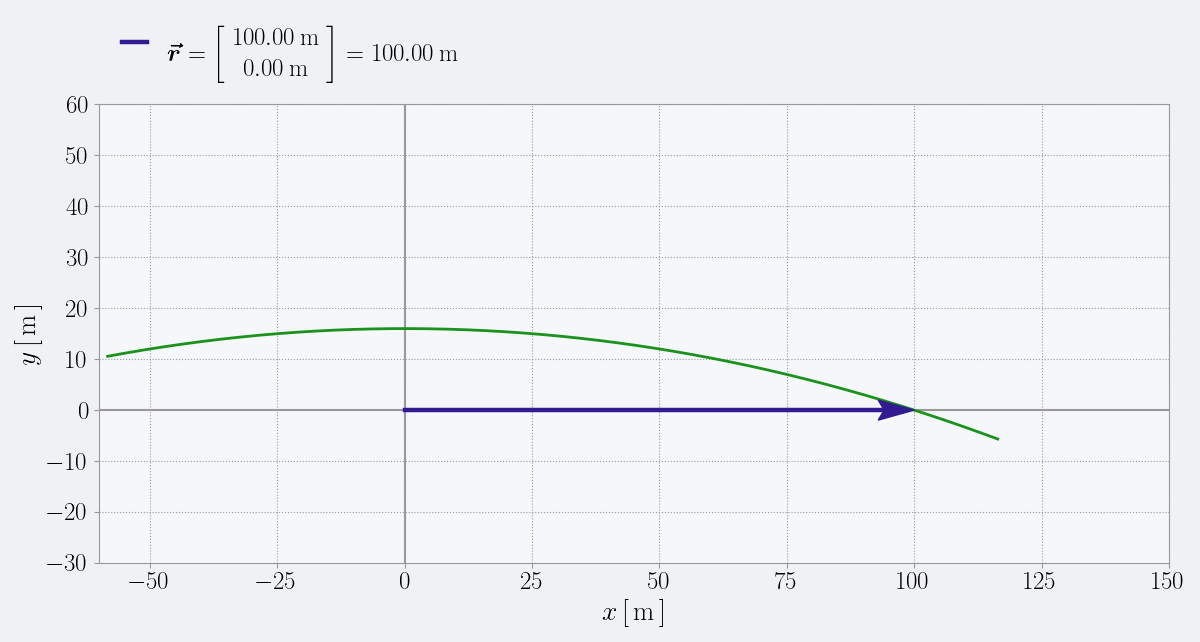

In [84]:
display(ui)
plt.tight_layout(pad = 0.5)
plt.show()